<a href="https://akademie.datamics.com/kursliste/">![title](bg_datamics_top.png)</a><center><em>© Datamics</em></center><br><center><em>Besuche uns für mehr Informationen auf <a href='https://akademie.datamics.com/kursliste/'>www.akademie.datamics.com</a></em>

# Decision Trees und Random Forests Projekt

Für dieses Projekt werden wir öffentlich verfügbare Daten von [LendingClub.com](https://de.wikipedia.org/wiki/Lending_Club) verwenden. Lending Club bringt Leute zusammen, die Geld brauchen (Leihende) und solche, die Geld investieren möchten (Geldgeber). Als Invester möchte man dann verständlicherweise vor allem an die Leute sein Geld verleihen, die es mit einer hohen Wahrscheinlichkeit zurückzahlen. Wir werden versuchen ein Modell zu erstellen, dass bei dieser Vorhersage hilft.

Wir werden Daten von 2007 bis 2010 verwenden, bevor das Unternehmen an die Börse ging. Anhand der Daten werden wir versuchen vorherzusagen, ob ein Leihender das Geld zurückgezahlt hat oder nicht. Die Daten haben wir als CSV in den Kursunterlagen beigefügt. Diese Datei wurde bereits um die nicht verfügbaren Einträge gesäubert.

Schauen wir uns noch die verfügbaren Spalten an:

* credit.policy: 1 falls der Kunde die Risikobewertung besteht, 0 falls nicht.
* purpose: Der Zweck des Kreidts (Werte sind "credit_card", "debt_consolidation", "educational", "major_purchase", "small_business", und "all_other").
* int.rate: Der Zinssatz des Kreidts als Anteil (eine Rate von 11% würde 0.11 sein). Kreditnehmer, die LendingClub.com als riskanter einstuft erhalten einen höheren Zins.
* installment: Die monatliche Zeilzahlung, die der Kreditnehmer leistet, wenn der Kredit finaziert wird.
* log.annual.inc: Der natürliche Log des angegebenen jährlichen Einkommens des Kreditnehmers.
* dti: Die "debt-to-income" Rate des Kreditnehmers (Kredit geteilt durch jährliches Einkommen.
* fico: Der FICO Kreditscore des Kreditnehmers.
* days.with.cr.line: Anzahl der Tage an denen der Kunde einen Dispokredit hatte.
* revol.bal: Die Bilanz am Ende eines Kreditkartenabrechnungszeitraums.
* revol.util: Der erstattete Anteil am Gesamtkredit.
* inq.last.6mths: Die Anzahl an Anfragen, die Kreditgeber in den letzten 6 Monaten an den Kreditnehmer gestellt haben.
* delinq.2yrs: Die Anzahl der Vorkommnisse eines Verzugs von über 30 Tagen innerhalb der letzten 2 Jahre.
* pub.rec:  Die Anzahl an negativen Einträgen (Bankrott, Steuerverzug, Verurteilungen,...) des Kreditnehmers.

## Libraries importieren

**Importiere die üblichen Libraries für Pandas und zur Visualisierung. Sklearn können wir später noch importieren.**

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Die Daten laden

**Nutze Pandas, um die Datei "Loan_Data.csv" als DataFrame namens "loans" zu laden.**

In [102]:
loans = pd.read_csv('Loan_Data.csv')

**Schau dir die info(), head() und describe() Methoden für loans an.**

In [103]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [104]:
loans.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


In [105]:
loans.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


## Explorative Daten Analyse

Visualisieren wir nun einige Daten! Wie nutzen dazu Seaborn und Pandas eingebaute VIsualisierungsfähigkeiten. Wer möchte kann aber auch andere Methoden verwenden. Die Farben müssen z.B. nicht genau übereinstimmen. Es geht hier darum ein Verständnis für die Daten zu entwickeln!

**Erstelle ein Histogram zweier FICO Verteilungen übereinandern, je eins nach dem credit.policy Ergebnis.**

*Hinweis: Das ist bereits etwas knifflig. Keine Sorge, die Lösung hilft im Zweifelsfall weiter! Meine Empfehlung ist die Verwendung von Pandas .hist() Funktion.*

Text(0.5, 0, 'FICO')

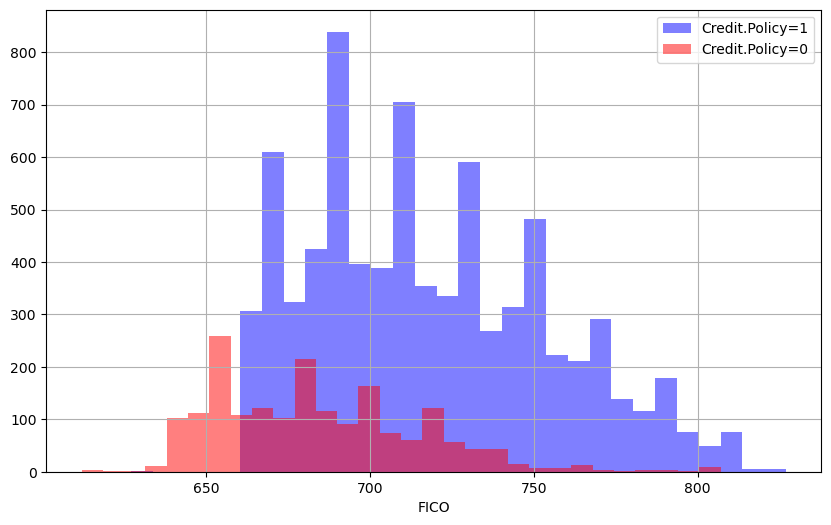

In [106]:
plt.figure(figsize=(10,6))
loans[loans['credit.policy']==1]['fico'].hist(alpha=0.5,color='blue',
                                              bins=30,label='Credit.Policy=1')
loans[loans['credit.policy']==0]['fico'].hist(alpha=0.5,color='red',
                                              bins=30,label='Credit.Policy=0')
plt.legend()
plt.xlabel('FICO')

**Erstelle ein gleiches Diagramm, dass diesesmal nach der "not.fully.paid" Spalte trennt.**

Text(0.5, 0, 'FICO')

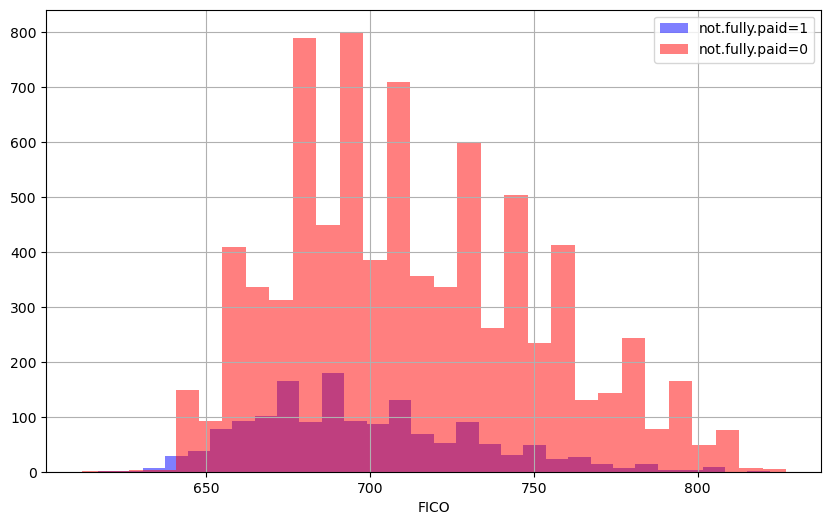

In [107]:
plt.figure(figsize=(10,6))
loans[loans['not.fully.paid']==1]['fico'].hist(alpha=0.5,color='blue',
                                              bins=30,label='not.fully.paid=1')
loans[loans['not.fully.paid']==0]['fico'].hist(alpha=0.5,color='red',
                                              bins=30,label='not.fully.paid=0')
plt.legend()
plt.xlabel('FICO')

**Erstelle ein Countplot unter Verwendung von Seaborn, das die Anzahl der Leihgaben (en. loans) nach Zweck (en. purpose) anzeigt. Der Hue soll dabei durch die Spalte "not.fully.paid" definiert sein.**

<Axes: xlabel='purpose', ylabel='count'>

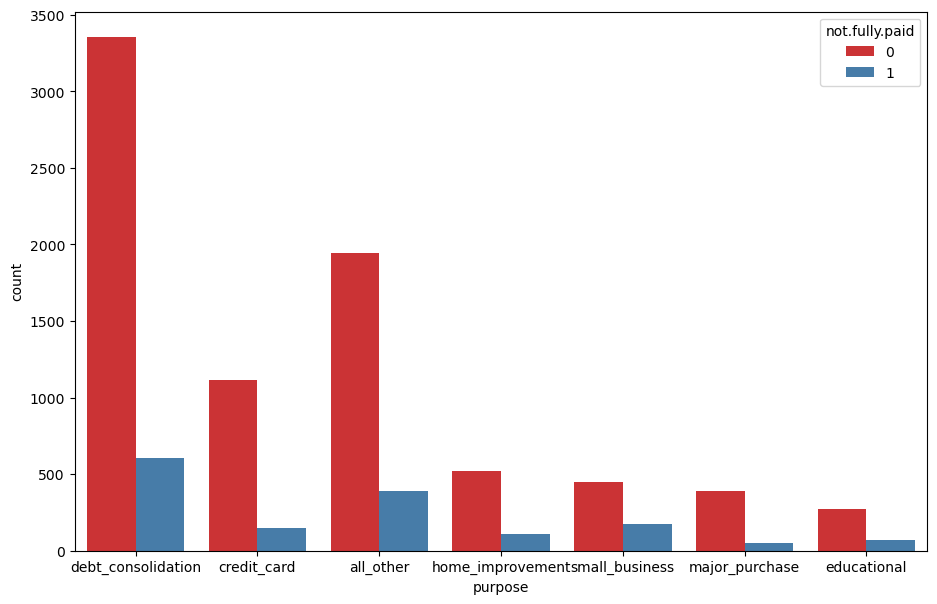

In [108]:
plt.figure(figsize=(11,7))
sns.countplot(x='purpose',hue='not.fully.paid',data=loans,palette='Set1')

**Lasst uns den Trend zwischen FICO Score und den Zinsen (en. interest rate) betrachten. Stelle dazu das folgende Jointplot nach.**

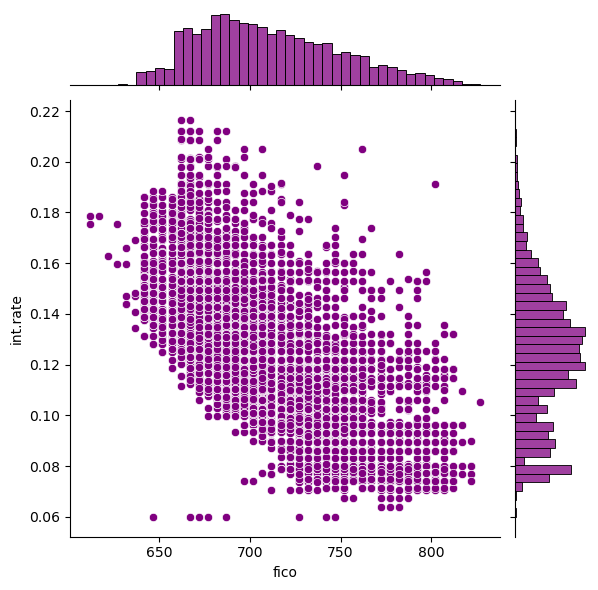

In [109]:
sns.jointplot(x='fico',y='int.rate',data=loans,color='purple')

**Erstelle die folgenden lmplots, um zu sehen, ob sich der Trend zwischen "not.fully.paid" und "credit.policy" unterscheidet. Schau in die Dokumentation von lmplot, wenn du nicht mehr weißt, wie man in zwei Spalten aufteilt.**

<Figure size 1100x700 with 0 Axes>

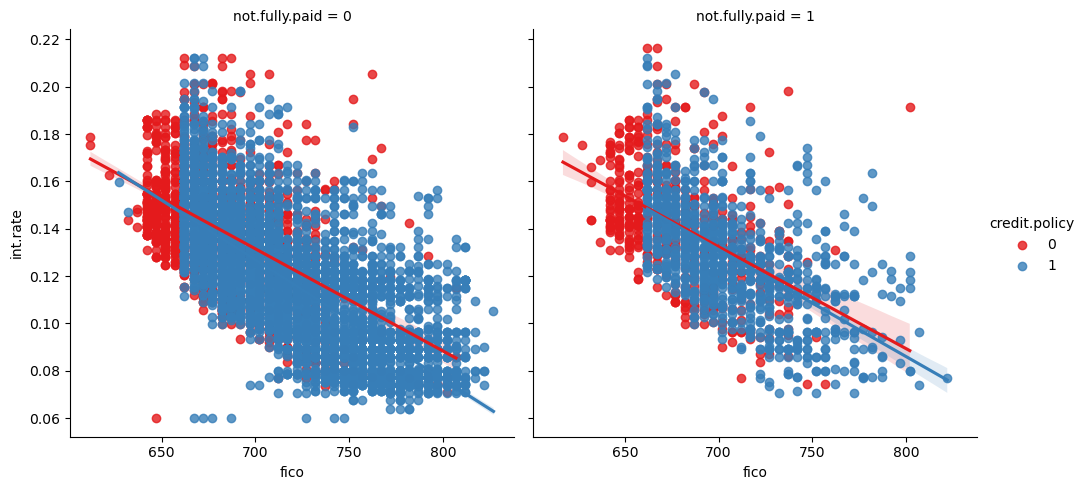

In [110]:
plt.figure(figsize=(11,7))
sns.lmplot(y='int.rate',x='fico',data=loans,hue='credit.policy',
           col='not.fully.paid',palette='Set1')

## Die Daten vorbereiten

Bereiten wir unsere Daten nun für ein Random Forest Klassifikationsmodell vor!

**Schaue dir erneut loans.info() an.**

In [111]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


### Kategorische Eigenschaften

Achte darauf, dass die Spalte "purpose" (dt. Zweck) kategorisch ist. Das bedeutet wir müssen sie in Dummy-Variablen umwandeln, damit sklearn mit ihnen arbeiten kann. Für diesen Schritt verwenden wir `pd.get_dummies`.

Dieses Vorgehen kann auf weitere kategorische Inhalte angewendet werden, wenn es nötig sein sollte.

**Erstelle eine Liste, die nur ein Element enthält. Dieses Element soll der String "purpose" sein. Nenne diese Liste cat_feats.**

In [112]:
cat_feats = ['purpose']

**Nutze jetzt pd.get_dummies(loans,columns=cat_feats,drop_first=True), um einen korrigierten und größeren DataFrame zu erstellen. Nenne diesen DataFrame final_data.**

*Hinweis: Um mehrere kategorische Eigenschaften in Dummy-Variablen zu übertragen füge die entsprechenden Spalten einfach der Liste aus dem vorherigen Arbeitsschritt hinzu. Für unseren Datensatz hier müssen wir allerdings keine weitere Spalte berücksichtigen.*

In [113]:
final_data = pd.get_dummies(loans,columns=cat_feats,drop_first=True)

In [114]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   credit.policy               9578 non-null   int64  
 1   int.rate                    9578 non-null   float64
 2   installment                 9578 non-null   float64
 3   log.annual.inc              9578 non-null   float64
 4   dti                         9578 non-null   float64
 5   fico                        9578 non-null   int64  
 6   days.with.cr.line           9578 non-null   float64
 7   revol.bal                   9578 non-null   int64  
 8   revol.util                  9578 non-null   float64
 9   inq.last.6mths              9578 non-null   int64  
 10  delinq.2yrs                 9578 non-null   int64  
 11  pub.rec                     9578 non-null   int64  
 12  not.fully.paid              9578 non-null   int64  
 13  purpose_credit_card         9578 

## Unit Testing und Logging für ML‑Modelle 

### Imports

In [115]:
import time
import json
import functools
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### Logger- und Timer‑Dekoratoren: Verzeichnis anlegen, Funktionsaufrufe protokollieren und Laufzeiten messen

In [116]:
# Hilfsfunktion: Verzeichnis sicherstellen
def ensure_dir_for_file(path: str):
    d = os.path.dirname(path)
    if d:
        os.makedirs(d, exist_ok=True)

# my_logger: schreibt JSON-Zeilen in logfile
def my_logger(logfile: str):
    ensure_dir_for_file(logfile)
    def decorator(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            entry = {
                "timestamp": time.time(),
                "func": func.__name__,
                "args_repr": repr(args),
                "kwargs_repr": repr(kwargs)
            }
            try:
                with open(logfile, "a") as f:
                    f.write(json.dumps(entry) + "\n")
            except Exception as e:
                print(f"[logger] write failed: {e}")
            return func(*args, **kwargs)
        return wrapper
    return decorator

# my_timer: misst Dauer und schreibt JSON-Zeilen in logfile
def my_timer(logfile: str):
    ensure_dir_for_file(logfile)
    def decorator(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            start = time.time()
            result = func(*args, **kwargs)
            duration = time.time() - start
            entry = {
                "timestamp": time.time(),
                "func": func.__name__,
                "duration_sec": duration
            }
            try:
                with open(logfile, "a") as f:
                    f.write(json.dumps(entry) + "\n")
            except Exception as e:
                print(f"[timer] write failed: {e}")
            # zusätzlich kurze Konsoleausgabe
            print(f"[timer] {func.__name__} took {duration:.4f}s")
            return result
        return wrapper
    return decorator

# liest aus der logfile die letzte Dauer für func_name aus
def read_last_duration(logfile: str, func_name: str):
    last_duration = None

    with open(logfile, "r") as f:
        for line in f:
            entry = json.loads(line)

            if entry["func"] == func_name:
                last_duration = entry["duration_sec"]

    return last_duration


### Wrapperklassen für Decision Tree und Random Forest mit integriertem Logging und Laufzeitmessung

In [117]:
# Wrapperklassen
LOG_DIR = "logs"
DT_FIT_LOG = f"{LOG_DIR}/dt_fit_calls.log"
DT_FIT_TIME = f"{LOG_DIR}/dt_fit_times.log"
DT_PRED_LOG = f"{LOG_DIR}/dt_predict_calls.log"
DT_PRED_TIME = f"{LOG_DIR}/dt_predict_times.log"

RF_FIT_LOG = f"{LOG_DIR}/rf_fit_calls.log"
RF_FIT_TIME = f"{LOG_DIR}/rf_fit_times.log"
RF_PRED_LOG = f"{LOG_DIR}/rf_predict_calls.log"
RF_PRED_TIME = f"{LOG_DIR}/rf_predict_times.log"

class DecisionTreeWrapper:
    def __init__(self, **kwargs):
        self.model = DecisionTreeClassifier(**kwargs)

    @my_logger(DT_FIT_LOG)
    @my_timer(DT_FIT_TIME)
    def fit(self, X, y):
        return self.model.fit(X, y)

    @my_logger(DT_PRED_LOG)
    @my_timer(DT_PRED_TIME)
    def predict(self, X):
        return self.model.predict(X)

class RandomForestWrapper:
    def __init__(self, **kwargs):
        self.model = RandomForestClassifier(**kwargs)

    @my_logger(RF_FIT_LOG)
    @my_timer(RF_FIT_TIME)
    def fit(self, X, y):
        return self.model.fit(X, y)

    @my_logger(RF_PRED_LOG)
    @my_timer(RF_PRED_TIME)
    def predict(self, X):
        return self.model.predict(X)


### Train/Test Split und Erzeugung der Decision Tree und Random Forest Wrapper‑Instanzen

In [118]:
# Train/Test Split 
X = final_data.drop('not.fully.paid', axis=1)
y = final_data['not.fully.paid']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

# Erzeuge Wrapper-Instanzen 
dtree = DecisionTreeWrapper(random_state=101)
rfc = RandomForestWrapper(n_estimators=600, random_state=101)


### Training und Evaluation der Modelle mit automatischem Logging von Aufrufen und Laufzeiten

In [119]:
# Trainieren und Evaluieren (Logs werden geschrieben)
print("Training Decision Tree...")
dtree.fit(X_train, y_train)
predictions_dt = dtree.predict(X_test)
print("Decision Tree classification report:")
print(classification_report(y_test, predictions_dt))
print("Decision Tree confusion matrix:")
print(confusion_matrix(y_test, predictions_dt))

print("\nTraining Random Forest...")
rfc.fit(X_train, y_train)
predictions_rf = rfc.predict(X_test)
print("Random Forest classification report:")
print(classification_report(y_test, predictions_rf))
print("Random Forest confusion matrix:")
print(confusion_matrix(y_test, predictions_rf))


Training Decision Tree...
[timer] fit took 0.0927s
[timer] predict took 0.0018s
Decision Tree classification report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      2431
           1       0.19      0.24      0.21       443

    accuracy                           0.72      2874
   macro avg       0.52      0.53      0.52      2874
weighted avg       0.75      0.72      0.74      2874

Decision Tree confusion matrix:
[[1975  456]
 [ 336  107]]

Training Random Forest...
[timer] fit took 8.5322s
[timer] predict took 0.2912s
Random Forest classification report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2431
           1       0.52      0.03      0.05       443

    accuracy                           0.85      2874
   macro avg       0.69      0.51      0.48      2874
weighted avg       0.80      0.85      0.78      2874

Random Forest confusion matrix:
[[2420   11]
 [ 431 

### Repräsentative Trainingslaufzeit messen

In [120]:
model_for_measure = DecisionTreeWrapper(random_state=42)
model_for_measure.fit(X_train, y_train)
duration = read_last_duration("logs/dt_fit_times.log", "fit")
print(f"Repräsentative fit-Laufzeit: {duration:.4f}s")


[timer] fit took 0.0870s
Repräsentative fit-Laufzeit: 0.0870s


### Unittests zur Validierung von predict und fit inklusive Accuracy‑ und Laufzeitprüfungen

In [ ]:
# Unittests
import unittest

class TestModelFunctions(unittest.TestCase):
    @classmethod
    def setUpClass(cls):
        cls.X_train = X_train
        cls.y_train = y_train
        cls.X_test = X_test
        cls.y_test = y_test
        cls.rep_fit = duration

    def test_predict_accuracy_and_confusion(self):
        model = DecisionTreeWrapper(random_state=42)
        model.fit(self.X_train, self.y_train)
        preds = model.predict(self.X_test)
        acc = accuracy_score(self.y_test, preds)
        cm = confusion_matrix(self.y_test, preds)
        print(f"\n[test] Accuracy: {acc:.4f}")
        print(f"[test] Confusion matrix:\n{cm}")
        self.assertGreaterEqual(acc, 0.65, f"Accuracy zu niedrig: {acc:.3f}")
        self.assertEqual(cm.shape, (2, 2))

    def test_fit_runtime_within_threshold(self):
        model = DecisionTreeWrapper(random_state=42)
        model.fit(self.X_train, self.y_train)
        limit = 1.2 * self.rep_fit
        print(f"\n[test] Measured fit duration: {duration:.4f}s, limit: {limit:.4f}s")
        self.assertLessEqual(duration, limit, f"Training dauerte {duration:.2f}s, Limit {limit:.2f}s überschritten")

# Tests ausführen
suite = unittest.defaultTestLoader.loadTestsFromTestCase(TestModelFunctions)
runner = unittest.TextTestRunner(verbosity=2)
runner.run(suite)


test_fit_runtime_within_threshold (__main__.TestModelFunctions.test_fit_runtime_within_threshold) ... 

ok
test_predict_accuracy_and_confusion (__main__.TestModelFunctions.test_predict_accuracy_and_confusion) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.201s

OK


[timer] fit took 0.0874s

[test] Measured fit duration: 0.0870s, limit: 0.1044s
[timer] fit took 0.0814s
[timer] predict took 0.0017s

[test] Accuracy: 0.7276
[test] Confusion matrix:
[[1990  441]
 [ 342  101]]


<unittest.runner.TextTestResult run=2 errors=0 failures=0>